In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

import time

In [18]:
class Perceptron:
    def __init__(self, learning_rate, boundary):
        self.learning_rate = learning_rate
        self.boundary = boundary
        self.weights_history = []

    def activation_function(self, potential):
        return 1 if potential >= 0 else 0

    def fit(self, X, labels, w, epochs, batch_size):
        """
        Learning algorithm with batch system
        """

        # First start with a initialized weights vector
        self.weights_history = [w.copy()]
        print(f"W[0] = {w} ")
        start = time.perf_counter()
        for epoch in range(epochs):
            print("Época ", epoch)
            errors_in_epoch = 0
            for i in range(0, len(X), batch_size):
                X_batch = X[i : i + batch_size]
                labels_batch = labels[i : i + batch_size]
                correction = np.zeros_like(w)
                
                for j in range(len(X_batch)):
                    potential = np.dot(X_batch[j], w) - self.boundary
            
                    y = self.activation_function(potential)
    
                    error = labels_batch[j] - y
                    if error != 0:
                        errors_in_epoch += 1

                    
                    correction += error * X_batch[j]

                if np.any(correction != 0):
                    w = w + self.learning_rate * correction
                    self.weights_history.append(w.copy())

                    print(f"Batch iniciado en {i}: w = {w}")
                    
            if errors_in_epoch == 0:
                print(f"El sistema convergió en la época {epoch}")
                break

        elapsed = time.perf_counter() - start
        print(f'Batch algorithm lasts {elapsed}s')
    def get_weights_history(self):
        return self.weights_history

In [19]:
X = [[2, 5], [3, 4], [3, 6],
     [5, 1], [8, 2], [4, 5],
     [4, 6], [6, 1], [6, 2],
     [7, 3]]
labels = [0, 0, 0, 1, 1, 0, 0, 1, 1, 1]

X = np.asarray(X, dtype=np.float64)
labels = np.asarray(labels, dtype=np.int8)
print(X.shape)
print(labels.shape)

(10, 2)
(10,)


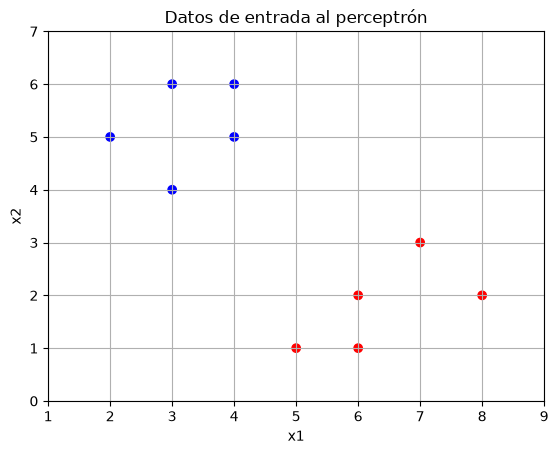

In [20]:
fig, ax = plt.subplots()

ax.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="bwr"
)

ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid()

line, = ax.plot([], [], color="black")
ax.set_title('Datos de entrada al perceptrón')
plt.show()

In [21]:
w = np.zeros(X.shape[1], dtype=np.float64)
learning_rate = 0.5
boundary = 1
epochs = 10
batch_size = 3

print(w.shape)

(2,)


In [22]:
perceptron = Perceptron(learning_rate, boundary)

perceptron.fit(X, labels, w, epochs, batch_size)

W[0] = [0. 0.] 
Época  0
Batch iniciado en 3: w = [6.5 1.5]
Batch iniciado en 6: w = [ 4.5 -1.5]
Época  1
Batch iniciado en 0: w = [ 0.5 -9. ]
Batch iniciado en 3: w = [ 7.  -7.5]
Época  2
El sistema convergió en la época 2
Batch algorithm lasts 0.0006439999997382984s


In [10]:
x1 = np.linspace(
    X[:, 0].min() - 1,
    X[:, 0].max() + 1,
    100
)

def update(frame):
    w_h = perceptron.weights_history[frame]

    if w_h[1] != 0:
        x2 = (perceptron.boundary - w_h[0] * x1) / w_h[1]
        line.set_data(x1, x2)
    else:
        line.set_data([], [])

    ax.set_title(f"Actualización {frame}")

    return line,

In [11]:
animation = FuncAnimation(
    fig,
    update,
    frames=len(perceptron.weights_history),
    interval=500,
    repeat=False
)

plt.close()
HTML(animation.to_jshtml())